In [3]:
import importlib.util
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

import importlib
import analytics
importlib.reload(analytics)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


<module 'analytics' from '/Users/gab/Library/Mobile Documents/com~apple~CloudDocs/QuIST/Projekt-Praktikum/codebase/groundstate_prep/analytics.py'>

In [35]:
### H_params = [J, h, N]
H_params = [1., 2., 6]

### T_params = [T, tau]
T_params = [0.75, 0.25]
T_params = [20, 0.25]

### C_params = [alpha, sigma, omega_max]
#C_params = [0.35, .2, 4.0] -> to wrong fixpoint

C_params = [0.5, .4, 7.0]
C_params = [0.25, 3., 6]


#### inverse temperature
beta = 1

def parameter_check(C_params, T_params, H_params=H_params):
    _, _, N = H_params
    alpha, sigma, omega_max = C_params
    T, tau = T_params
    tmix= N^2
    print (f"$T \\cdot \\alpha$ = {T* alpha}")
    print (f"t_mix = {tmix}")
    print (f"$\\sigma =   {sigma} \\approx$ {tmix/omega_max} ")

parameter_check(C_params, T_params)


$T \cdot \alpha$ = 5.0
t_mix = 4
$\sigma =   3.0 \approx$ 0.6666666666666666 


In [ ]:
t = 20

def f(C_args):
    
    T_params[0] = C_args[0]
    C_args = C_args[1:]


    _ , dist, _, _ = analytics.run_TFIM(H_params, T_params, C_args, beta, timesteps=t, silent=True, plots=False, seed=42)
    return dist[0]

c0 = [20., 0.4, .5, 9.0]

result = minimize(f, c0, method="Nelder-Mead", options={
        "maxiter": 10,
        "maxfev": 20,
        "xtol":1e-2,
        "ftol":1e-3},
        bounds=[
        (0, None),
        (0.05, 0.5),
        (0.25,5),
        (6, 10)]
        )

print("best x:", result.x)
print("best value:", result.fun)
print("function evaluations:", result.nfev)
print("iterations:", result.nit)
print("success:", result.success)
print("message:", result.message)

[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

--------------------------------------------------------------------------------
Start calculation
--------------------------------------------------------------------------------

Transversal Ising XXZ model on 6 qubits with J = 1.0 , h = 2.0 :

H_sys = -1.0 * (Z(0) @ Z(1)) + -1.0 * (Z(1) @ Z(2)) + -1.0 * (Z(2) @ Z(3)) + -1.0 * (Z(3) @ Z(4)) + -1.0 * (Z(4) @ Z(5)) + -1.0 * (Z(5) @ Z(0)) + -2.0 * X(0) + -2.0 * X(1) + -2.0 * X(2) + -2.0 * X(3) + -2.0 * X(4) + -2.0 * X(5) 

10  timesteps:	 0.869
20  timesteps:	 0.812
					 trace dist. increment 0.881
30  timesteps:	 0.786
					 trace dist. increment 0.773
40  timesteps:	 0.757
					 trace dist. increment 0.68
50  timesteps:	 0.703
					 trace dist. increment 0.611
60  timesteps:	 0.666
					 trace dist. increment 0.502
70  timesteps:	 0.589
					 trace dist. increment 0.417
80  timesteps:	 0.564
					 trace dist. increment 0.298
90  timesteps:	 0.559
					 trace dist. increment 0.259
100  timest

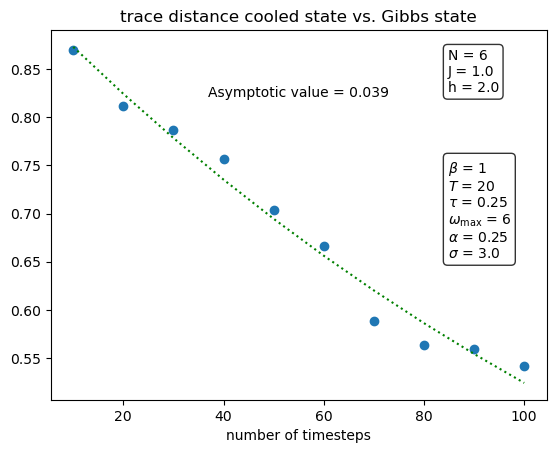

In [ ]:
N=10
t = [10*i for i in range(1,N+1)]
print(t)
T_params = [20, 0.25]
C_params = [0.25, 3., 6]

t, dist, increments, p = analytics.run_TFIM(H_params, T_params, C_params, beta, timesteps=t, seed=42)
_, p_fit, cov = analytics.extract_asymptotics(t, dist)


445.0 iterations necessary for level eps <  0.1


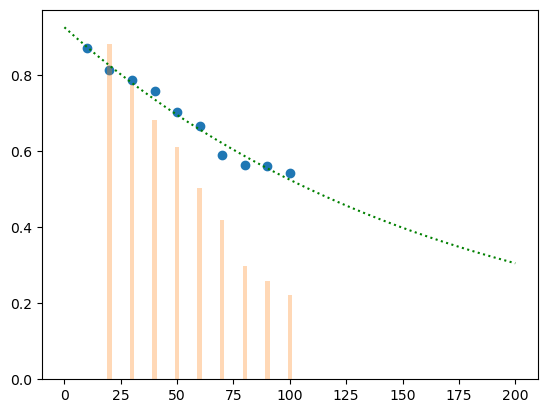

In [31]:
x = np.linspace(0,200,201)
y = analytics.exp_model(x, *p_fit)

fig, ax = plt.subplots()

ax.scatter(t, dist)
ax.plot(x,y, color="green", ls=":")
ax.bar(t[1:], increments[1:], width=2, alpha=0.3, label="increments")


level = 0.1
a, b, c = p_fit
if level>a:
    n = np.log((level - a) / b) / c
    print(np.ceil(n), 'iterations necessary for level eps < ', level)
else:
    print("level", level, "not reachable")

In [37]:
beta = 1
tau0 = 0.25
T_params_sweep = [ [i, tau0] for i in range(5,30,5)]
C_params_sweep = [[0.05*i, 0.35, 7] for i in range(1,5) ] 

i = 1
results = []
print(len(T_params_sweep)*len(C_params_sweep), "sweeps:\n")
for C_params in C_params_sweep:
    for T_params in T_params_sweep:
        res = analytics.run_TFIM(H_params, T_params, C_params, beta, timesteps=10, silent=True, plots=False) 
        print("sweep", i, ": ", res[1][-1])
        results.append(res)
        i += 1

values = [res[1][-1] for res in results]
idx = np.argmin(values)
best = results[idx]
print(best[3])

20 sweeps:

sweep 1 :  0.9527894675436526
sweep 2 :  0.9387679710854067
sweep 3 :  0.9522173714925516
sweep 4 :  0.9441754630707333
sweep 5 :  0.9219400186326908
sweep 6 :  0.9389515345936795
sweep 7 :  0.9229864329892759
sweep 8 :  0.9369635936600795
sweep 9 :  0.927743851461843
sweep 10 :  0.9078697226001553
sweep 11 :  0.9197169399099854
sweep 12 :  0.9006834776479506
sweep 13 :  0.915761550485761
sweep 14 :  0.9048768522075192
sweep 15 :  0.8882062526317607
sweep 16 :  0.8965168182600752
sweep 17 :  0.8735481678886929
sweep 18 :  0.8900489249675307
sweep 19 :  0.8772605104150404
sweep 20 :  0.8641040401194571
{'N': 6, 'J': 1.0, 'h': 2.0, 'beta': 1, 'T': 25, 'tau': 0.25, 'alpha': 0.2, 'sigma': 0.35, 'omega_max': 7, 'ops': 'XZ', 'mixed': True, 'seed': 12}


### Construct Channel as superoperator ###